In [1]:
import numpy as np
from InfAdjFPFiniteDiffApp import InfAdjFPFiniteDiff_OriginalOperator
import matplotlib.pyplot as plt

In [2]:
dim = 1
V0 = 1e-10
v0 = V0 / 24 * np.pi * np.pi
beta = 0.01
deltaPhiWell = 2 * (2 / 3 * v0 / beta) ** (1 / 3)
phi0 = 0.5 * deltaPhiWell + 0.3 / np.sqrt(beta)

def infPotFunc(phi):
    x = phi - phi0
    return float(V0 * (1 + beta * x * x * x))

def infPotDerivFunc(phi):
    x = phi - phi0
    return float(3 * V0 * beta * x * x)

def infPotDeriv2Func(phi):
    x = phi - phi0
    return float(6 * V0 * beta * x)

infPotentialDerivFuncs = [infPotDerivFunc]
infPotentialDeriv2Funcs = [infPotDeriv2Func]

upperBound = phi0 + deltaPhiWell
lowerBound = phi0 - deltaPhiWell
nGrid = 4096  

In [3]:
fpFinDiff_DirNeu = InfAdjFPFiniteDiff_OriginalOperator(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    [nGrid],
    [upperBound],
    [lowerBound],
    ["Neumann0"],
    ["Dirichlet"]
)

eigVals_DirNeu, eigVecs_DirNeu = np.linalg.eig(fpFinDiff_DirNeu)
eigVecsSort_DirNeu = eigVecs_DirNeu.T[np.argsort(eigVals_DirNeu)]
eigValsSort_DirNeu = np.sort(eigVals_DirNeu)

In [4]:
fpFinDiff_DirDir = InfAdjFPFiniteDiff_OriginalOperator(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    [nGrid],
    [upperBound],
    [lowerBound],
    ["Dirichlet"],
    ["Dirichlet"]
)

eigVals_DirDir, eigVecs_DirDir = np.linalg.eig(fpFinDiff_DirDir)
eigVecsSort_DirDir = eigVecs_DirDir.T[np.argsort(eigVals_DirDir)]
eigValsSort_DirDir = np.sort(eigVals_DirDir)

In [5]:
fpFinDiff_DirDir[:10,:10]

array([[ 0.45220232, -0.14017366,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [-0.31194475,  0.45220232, -0.14025757,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        , -0.31186088,  0.45220232, -0.14034145,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        , -0.31177705,  0.45220232, -0.14042528,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , -0.31169326,  0.45220232,
        -0.14050907,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        , -0.31160951,
         0.45220232, -0.14059282,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        -0.3115258 ,  0.45220232, -0.14067653

c:\Users\koich\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


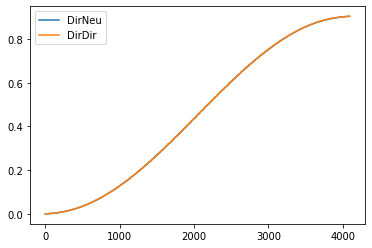

In [6]:
nMode = np.arange(nGrid)

ax = plt.gca()
plt.plot(nMode, eigValsSort_DirNeu, label = "DirNeu")
plt.plot(nMode, eigValsSort_DirDir, label = "DirDir")
plt.legend()
plt.show()

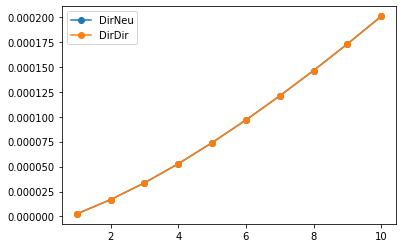

In [7]:
ax = plt.gca()
plt.plot(np.arange(1, 11), eigValsSort_DirNeu[:10], marker='o', label = "DirNeu")
plt.plot(np.arange(1, 11), eigValsSort_DirDir[:10], marker='o', label = "DirDir")
plt.legend()
plt.show()

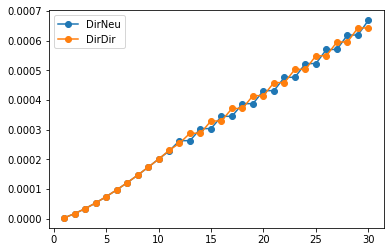

In [8]:
ax = plt.gca()
plt.plot(np.arange(1, 31), eigValsSort_DirNeu[:30], marker='o', label = "DirNeu")
plt.plot(np.arange(1, 31), eigValsSort_DirDir[:30], marker='o', label = "DirDir")
plt.legend()
plt.show()

In [9]:
print(eigValsSort_DirNeu[:10])
print(eigValsSort_DirDir[:10])

[2.56487001e-06+0.j 1.69238863e-05+0.j 3.36400323e-05+0.j
 5.28292499e-05+0.j 7.39404191e-05+0.j 9.66780451e-05+0.j
 1.20837764e-04+0.j 1.46271494e-04+0.j 1.72842424e-04+0.j
 2.00674837e-04+0.j]
[2.56487000e-06+0.j 1.69238863e-05+0.j 3.36400324e-05+0.j
 5.28292500e-05+0.j 7.39404211e-05+0.j 9.66780276e-05+0.j
 1.20837967e-04+0.j 1.46269331e-04+0.j 1.72864859e-04+0.j
 2.00446267e-04+0.j]


「下端：ディリクレ、上端：ノイマン」と「下端：ディリクレ、上端：ノイマン」で、固有値ほぼ一致

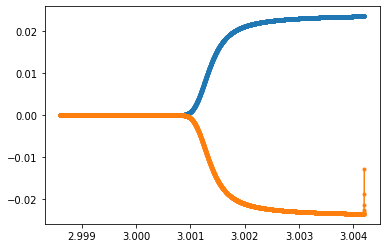

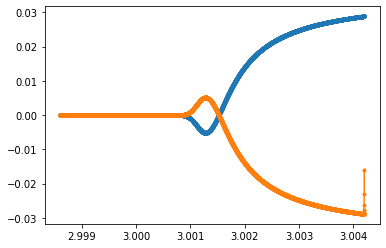

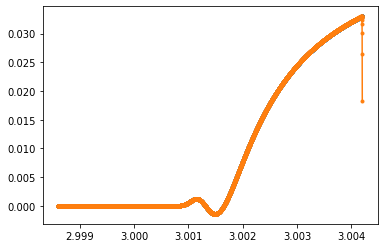

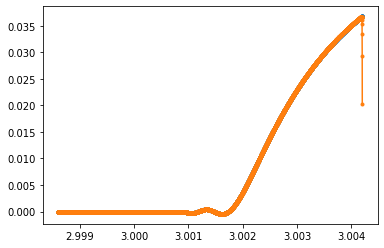

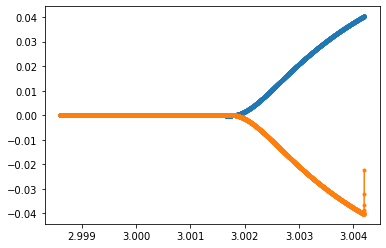

In [10]:
# 固有関数のプロット（-1倍の違いがある場合もあるが、それを除けば一致）
grids = np.flip(np.linspace(upperBound, lowerBound, nGrid, endpoint=False))

ax = plt.gca()

for iEig in range(5):
    plt.plot(grids, eigVecsSort_DirNeu[iEig],marker='.', label="DirNeu")
    plt.plot(grids, eigVecsSort_DirDir[iEig],marker='.', label="DirDir")
    plt.show()

領域を広げてみる

In [11]:
upperBound_wide = phi0 + deltaPhiWell * 5
lowerBound_wide = phi0 - deltaPhiWell * 5

In [12]:
fpFinDiff_DirNeu_wide = InfAdjFPFiniteDiff_OriginalOperator(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    [nGrid],
    [upperBound_wide],
    [lowerBound_wide],
    ["Neumann0"],
    ["Dirichlet"]
)

eigVals_DirNeu_wide, eigVecs_DirNeu_wide = np.linalg.eig(fpFinDiff_DirNeu_wide)
eigVecsSort_DirNeu_wide = eigVecs_DirNeu_wide.T[np.argsort(eigVals_DirNeu_wide)]
eigValsSort_DirNeu_wide = np.sort(eigVals_DirNeu_wide)

In [13]:
fpFinDiff_DirDir_wide = InfAdjFPFiniteDiff_OriginalOperator(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    [nGrid],
    [upperBound_wide],
    [lowerBound_wide],
    ["Dirichlet"],
    ["Dirichlet"]
)

eigVals_DirDir_wide, eigVecs_DirDir_wide = np.linalg.eig(fpFinDiff_DirDir_wide)
eigVecsSort_DirDir_wide = eigVecs_DirDir_wide.T[np.argsort(eigVals_DirDir_wide)]
eigValsSort_DirDir_wide = np.sort(eigVals_DirDir_wide)

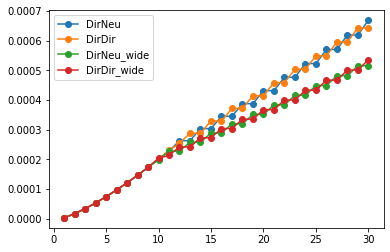

In [14]:
ax = plt.gca()
plt.plot(np.arange(1, 31), eigValsSort_DirNeu[:30], marker='o', label = "DirNeu")
plt.plot(np.arange(1, 31), eigValsSort_DirDir[:30], marker='o', label = "DirDir")
plt.plot(np.arange(1, 31), eigValsSort_DirNeu_wide[:30], marker='o', label = "DirNeu_wide")
plt.plot(np.arange(1, 31), eigValsSort_DirDir_wide[:30], marker='o', label = "DirDir_wide")
plt.legend()
plt.show()

固有関数のプロット

c:\Users\koich\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


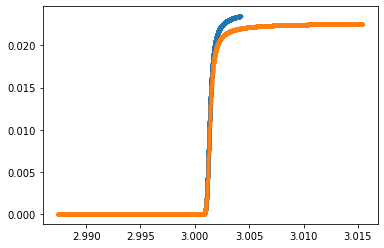

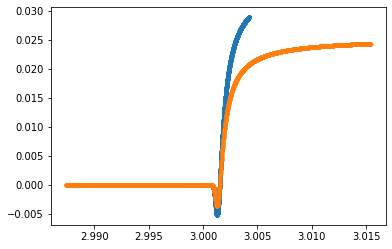

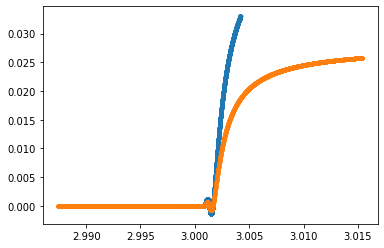

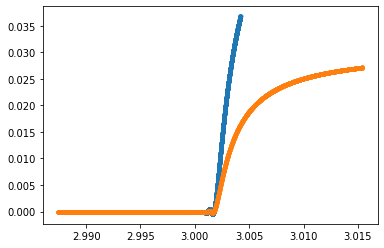

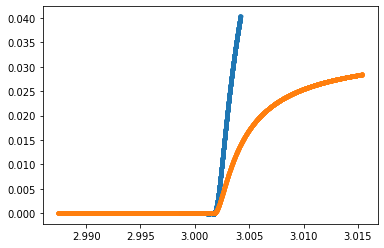

In [18]:
grids = np.flip(np.linspace(upperBound, lowerBound, nGrid, endpoint=False))
grids_wide = np.flip(np.linspace(upperBound_wide, lowerBound_wide, nGrid, endpoint=False))

ax = plt.gca()

# 符号調整
sgn =[-1, 1, -1, -1, -1]

for iEig in range(5):
    plt.plot(grids, eigVecsSort_DirNeu[iEig],marker='.', label="DirNeu")
    plt.plot(grids_wide, sgn[iEig] * eigVecsSort_DirNeu_wide[iEig],marker='.', label="DirNeu_wide")
    plt.show()

形状はかなり違うのに固有値は合うな...

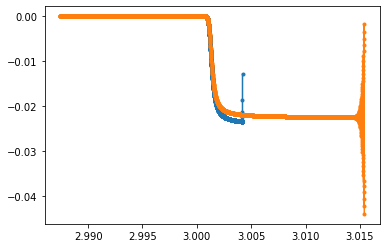

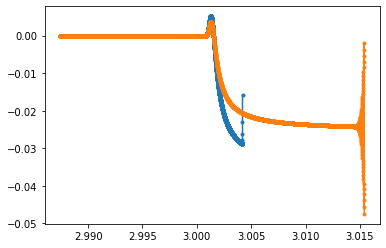

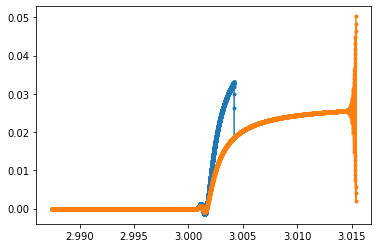

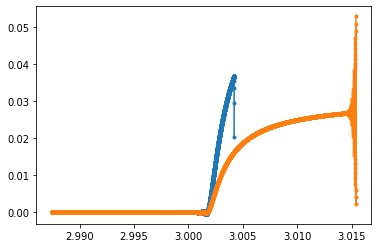

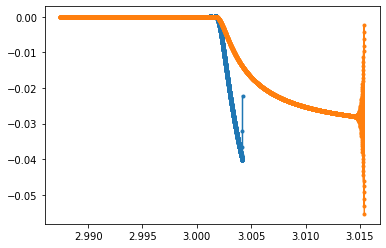

In [19]:
ax = plt.gca()

# 符号調整
sgn =[1, 1, -1, -1, 1]

for iEig in range(5):
    plt.plot(grids, eigVecsSort_DirDir[iEig],marker='.', label="DirDir")
    plt.plot(grids_wide, sgn[iEig] * eigVecsSort_DirDir_wide[iEig],marker='.', label="DirDir_wide")
    plt.show()

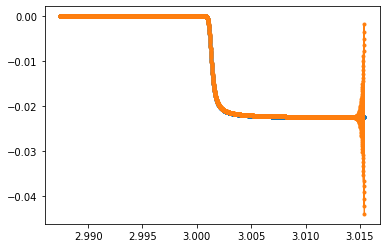

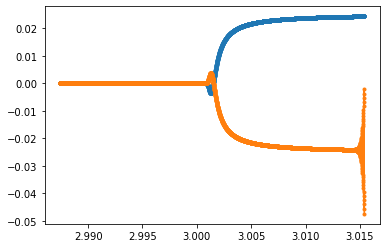

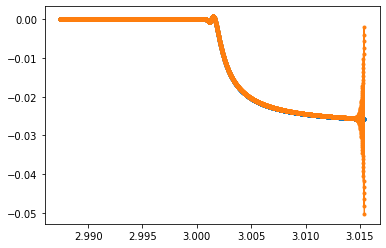

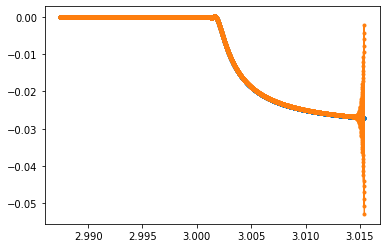

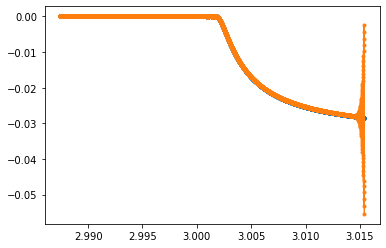

In [17]:
ax = plt.gca()

for iEig in range(5):
    plt.plot(grids_wide, eigVecsSort_DirNeu_wide[iEig],marker='.', label="DirNeu_wide")
    plt.plot(grids_wide, eigVecsSort_DirDir_wide[iEig],marker='.', label="DirDir_wide")
    plt.show()